In [1]:

import numpy as np
import scipy.stats as stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from numba import jit
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Environment setup complete.")
print("Libraries imported: numpy, scipy, matplotlib, numba")


Environment setup complete.
Libraries imported: numpy, scipy, matplotlib, numba


In [2]:

# Step 1: Analysis Plan
print("="*80)
print("ANALYSIS PLAN")
print("="*80)
print()
print("Research Question:")
print(" Is the low fragility score at zeta function peaks due to orthogonality")
print(" of the change vector ΔV to the main sum vector V_1, rather than")
print(" small change magnitude?")
print()
print("Step 1: Function and Ordinate Selection")
print(" - Function: Riemann zeta (a_n = 1 for all n)")
print(" - Base truncation: N = 10^6")
print(" - Ordinate range: t ∈ [5000, 15000]")
print(" - Find top 20 resonance peaks by |D(t; N)|")
print(" - Select 20 random ordinates (seed=42)")
print()
print("Step 2: Vector Calculation")
print(" For each of 40 ordinates (20 peaks + 20 random):")
print(" - Compute V_1 = D(t; N) using Kahan summation")
print(" - Compute V_2 = D(t; N+ΔN) using Kahan summation, ΔN = 1000")
print(" - Compute change vector ΔV = V_2 - V_1")
print()
print("Step 3: Component Analysis")
print(" For each ordinate, calculate:")
print(" - Relative magnitude: M_rel = |ΔV| / |V_1|")
print(" - Alignment angle: θ = acos(Re(V_1 * conj(ΔV)) / (|V_1| * |ΔV|))")
print(" - θ ≈ π/2 (90°) indicates orthogonality")
print()
print("Step 4: Statistical Comparison")
print(" - Mann-Whitney U tests to compare M_rel and θ between peak and random groups")
print(" - Report medians, p-values, and effect sizes (rank-biserial correlation)")
print()
print("Technical Requirements:")
print(" - Use Kahan compensated summation to avoid catastrophic cancellation")
print(" - Use JIT compilation (numba) for efficient computation")
print(" - Non-parametric statistics (Mann-Whitney) for non-normal distributions")
print()
print("="*80)


ANALYSIS PLAN

Research Question:
 Is the low fragility score at zeta function peaks due to orthogonality
 of the change vector ΔV to the main sum vector V_1, rather than
 small change magnitude?

Step 1: Function and Ordinate Selection
 - Function: Riemann zeta (a_n = 1 for all n)
 - Base truncation: N = 10^6
 - Ordinate range: t ∈ [5000, 15000]
 - Find top 20 resonance peaks by |D(t; N)|
 - Select 20 random ordinates (seed=42)

Step 2: Vector Calculation
 For each of 40 ordinates (20 peaks + 20 random):
 - Compute V_1 = D(t; N) using Kahan summation
 - Compute V_2 = D(t; N+ΔN) using Kahan summation, ΔN = 1000
 - Compute change vector ΔV = V_2 - V_1

Step 3: Component Analysis
 For each ordinate, calculate:
 - Relative magnitude: M_rel = |ΔV| / |V_1|
 - Alignment angle: θ = acos(Re(V_1 * conj(ΔV)) / (|V_1| * |ΔV|))
 - θ ≈ π/2 (90°) indicates orthogonality

Step 4: Statistical Comparison
 - Mann-Whitney U tests to compare M_rel and θ between peak and random groups
 - Report medians, p-

In [3]:

# Step 2: Implement Kahan summation for Dirichlet sum computation
# D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2 + it)
# For Riemann zeta, a_n = 1

@jit(nopython=True)
def compute_dirichlet_sum_kahan(t, N):
 """
 Compute Dirichlet sum D(t; N) = Σ_{n=1}^{N} 1 / n^(1/2 + it)
 using Kahan compensated summation.
 
 Parameters:
 -----------
 t : float
 Ordinate value
 N : int
 Truncation depth
 
 Returns:
 --------
 complex : D(t; N)
 """
 sum_real = 0.0
 sum_imag = 0.0
 c_real = 0.0 # compensation for real part
 c_imag = 0.0 # compensation for imaginary part
 
 for n in range(1, N + 1):
 # Compute 1 / n^(1/2 + it) = n^(-1/2) * exp(-i*t*log(n))
 n_sqrt = np.sqrt(float(n))
 log_n = np.log(float(n))
 angle = -t * log_n
 
 # Real and imaginary parts of the term
 term_real = np.cos(angle) / n_sqrt
 term_imag = np.sin(angle) / n_sqrt
 
 # Kahan summation for real part
 y_real = term_real - c_real
 t_real = sum_real + y_real
 c_real = (t_real - sum_real) - y_real
 sum_real = t_real
 
 # Kahan summation for imaginary part
 y_imag = term_imag - c_imag
 t_imag = sum_imag + y_imag
 c_imag = (t_imag - sum_imag) - y_imag
 sum_imag = t_imag
 
 return sum_real + 1j * sum_imag

# Test the function
print("Testing Dirichlet sum computation with Kahan summation...")
test_t = 1000.0
test_N = 1000
test_sum = compute_dirichlet_sum_kahan(test_t, test_N)
print(f"D(t={test_t}, N={test_N}) = {test_sum:.6f}")
print(f"|D(t={test_t}, N={test_N})| = {abs(test_sum):.6f}")
print("Function tested successfully.")


Testing Dirichlet sum computation with Kahan summation...


D(t=1000.0, N=1000) = 0.359844+0.899198j
|D(t=1000.0, N=1000)| = 0.968527
Function tested successfully.


In [4]:

# Step 3: Scan for resonance peaks in t ∈ [5000, 15000] at N = 10^6
# This is a coarse scan first, then we'll refine around peaks

print("="*80)
print("STEP 1: IDENTIFYING RESONANCE PEAKS")
print("="*80)
print()

N_base = 1000000 # 10^6
t_min = 5000.0
t_max = 15000.0

# Coarse scan with step size dt = 10
print(f"Performing coarse scan for |D(t; N={N_base})| in t ∈ [{t_min}, {t_max}]...")
print("This will take several minutes due to the large N value...")

dt_coarse = 10.0
t_values_coarse = np.arange(t_min, t_max + dt_coarse, dt_coarse)
magnitudes_coarse = np.zeros(len(t_values_coarse))

print(f"Number of points in coarse scan: {len(t_values_coarse)}")
print("Computing magnitudes... (progress updates every 100 points)")

for i, t in enumerate(t_values_coarse):
 D_t = compute_dirichlet_sum_kahan(t, N_base)
 magnitudes_coarse[i] = abs(D_t)
 if (i + 1) % 100 == 0:
 print(f" Progress: {i+1}/{len(t_values_coarse)} ({100*(i+1)/len(t_values_coarse):.1f}%)")

print("Coarse scan complete.")
print(f"Mean magnitude: {np.mean(magnitudes_coarse):.4f}")
print(f"Max magnitude: {np.max(magnitudes_coarse):.4f}")
print(f"Min magnitude: {np.min(magnitudes_coarse):.4f}")


STEP 1: IDENTIFYING RESONANCE PEAKS

Performing coarse scan for |D(t; N=1000000)| in t ∈ [5000.0, 15000.0]...
This will take several minutes due to the large N value...
Number of points in coarse scan: 1001
Computing magnitudes... (progress updates every 100 points)


 Progress: 100/1001 (10.0%)


 Progress: 200/1001 (20.0%)


 Progress: 300/1001 (30.0%)


 Progress: 400/1001 (40.0%)


...

 Progress: 600/1001 (59.9%)


 Progress: 700/1001 (69.9%)


 Progress: 800/1001 (79.9%)


 Progress: 900/1001 (89.9%)


 Progress: 1000/1001 (99.9%)
Coarse scan complete.
Mean magnitude: 1.9361
Max magnitude: 12.6181
Min magnitude: 0.0052


In [5]:

# Find peaks in the coarse scan
# Use scipy.signal.find_peaks with a prominence threshold

# Set prominence threshold based on the data
prominence_threshold = 2.0 # peaks should be at least 2 units above surroundings

peaks_idx, peak_properties = find_peaks(magnitudes_coarse, 
 prominence=prominence_threshold,
 distance=5) # peaks must be at least 5 points apart

print(f"\nFound {len(peaks_idx)} peaks with prominence > {prominence_threshold}")
print(f"Peak indices: {peaks_idx[:30]}") # show first 30

# Get the t values and magnitudes at these peaks
t_peaks_coarse = t_values_coarse[peaks_idx]
mag_peaks_coarse = magnitudes_coarse[peaks_idx]

# Sort by magnitude and select top 20
sorted_idx = np.argsort(mag_peaks_coarse)[::-1]
top_20_idx = sorted_idx[:20]

t_peaks_top20 = t_peaks_coarse[top_20_idx]
mag_peaks_top20 = mag_peaks_coarse[top_20_idx]

print(f"\nTop 20 resonance peaks:")
print(f"{'Rank':<6}{'t value':<12}{'|D(t; N)|':<12}")
print("-" * 30)
for i, (t, mag) in enumerate(zip(t_peaks_top20, mag_peaks_top20)):
 print(f"{i+1:<6}{t:<12.1f}{mag:<12.4f}")



Found 108 peaks with prominence > 2.0
Peak indices: [ 4 13 24 33 45 52 61 72 77 82 88 93 109 120 132 140 148 159
 168 180 188 200 207 216 227 237 246 256 266 276]

Top 20 resonance peaks:
Rank t value |D(t; N)| 
------------------------------
1 5130.0 12.6181 
2 6200.0 12.1711 
3 8230.0 12.0306 
4 13280.0 11.8580 
5 6680.0 11.7092 
6 13000.0 11.6579 
7 11330.0 11.4502 
8 14830.0 10.9935 
9 13480.0 10.8946 
10 11540.0 10.7917 
11 11450.0 10.2671 
12 6590.0 9.6023 
13 8150.0 9.3873 
14 6400.0 9.3807 
15 14640.0 8.9092 
16 5330.0 8.8470 
17 7070.0 8.8432 
18 14440.0 8.8192 
19 9500.0 8.5978 
20 13080.0 8.5631 


In [6]:

# Generate 20 random ordinates from the same range
# Use seed=42 for reproducibility (already set at the beginning)

t_random = np.random.uniform(t_min, t_max, size=20)
t_random = np.sort(t_random) # sort for easier tracking

print("="*80)
print("20 RANDOM ORDINATES (seed=42)")
print("="*80)
print()
print(f"{'Index':<8}{'t value':<12}")
print("-" * 20)
for i, t in enumerate(t_random):
 print(f"{i+1:<8}{t:<12.2f}")

print(f"\nRandom ordinate range: [{t_random.min():.2f}, {t_random.max():.2f}]")


20 RANDOM ORDINATES (seed=42)

Index t value 
--------------------
1 5205.84 
2 5580.84 
3 6559.95 
4 6560.19 
5 6818.25 
6 6834.05 
7 7123.39 
8 7912.29 
9 8042.42 
10 8745.40 
11 9319.45 
12 10247.56 
13 10986.58 
14 11011.15 
15 12080.73 
16 12319.94 
17 13324.43 
18 13661.76 
19 14507.14 
20 14699.10 

Random ordinate range: [5205.84, 14699.10]


In [7]:

# Step 4: For all 40 ordinates, compute V_1, V_2, and ΔV
# V_1 = D(t; N)
# V_2 = D(t; N + ΔN)
# ΔV = V_2 - V_1

print("="*80)
print("STEP 2: VECTOR CALCULATION FOR ALL ORDINATES")
print("="*80)
print()

N = N_base # 10^6
delta_N = 1000

# Combine all ordinates
all_ordinates = np.concatenate([t_peaks_top20, t_random])
ordinate_labels = ['peak'] * 20 + ['random'] * 20

print(f"Computing vectors for {len(all_ordinates)} ordinates...")
print(f"N = {N}, ΔN = {delta_N}")
print()

# Storage for results
V_1_all = np.zeros(40, dtype=complex)
V_2_all = np.zeros(40, dtype=complex)
delta_V_all = np.zeros(40, dtype=complex)

print("Computing V_1 = D(t; N) for all ordinates...")
for i, t in enumerate(all_ordinates):
 V_1_all[i] = compute_dirichlet_sum_kahan(t, N)
 if (i + 1) % 10 == 0:
 print(f" Progress: {i+1}/40")

print("\nComputing V_2 = D(t; N+ΔN) for all ordinates...")
for i, t in enumerate(all_ordinates):
 V_2_all[i] = compute_dirichlet_sum_kahan(t, N + delta_N)
 if (i + 1) % 10 == 0:
 print(f" Progress: {i+1}/40")

# Compute change vectors
delta_V_all = V_2_all - V_1_all

print("\nVector computation complete.")
print(f"\nSample results (first 5 ordinates):")
print(f"{'i':<4}{'t':<12}{'Type':<8}{'|V_1|':<12}{'|V_2|':<12}{'|ΔV|':<12}")
print("-" * 60)
for i in range(5):
 print(f"{i+1:<4}{all_ordinates[i]:<12.2f}{ordinate_labels[i]:<8}"
 f"{abs(V_1_all[i]):<12.4f}{abs(V_2_all[i]):<12.4f}{abs(delta_V_all[i]):<12.6f}")


STEP 2: VECTOR CALCULATION FOR ALL ORDINATES

Computing vectors for 40 ordinates...
N = 1000000, ΔN = 1000

Computing V_1 = D(t; N) for all ordinates...
 Progress: 10/40


 Progress: 20/40


 Progress: 30/40


 Progress: 40/40

Computing V_2 = D(t; N+ΔN) for all ordinates...


 Progress: 10/40
 Progress: 20/40


 Progress: 30/40


 Progress: 40/40

Vector computation complete.

Sample results (first 5 ordinates):
i t Type |V_1| |V_2| |ΔV| 
------------------------------------------------------------
1 5130.00 peak 12.6181 12.4522 0.213015 
2 6200.00 peak 12.1711 12.1847 0.013917 
3 8230.00 peak 12.0306 11.8300 0.200694 
4 13280.00 peak 11.8580 11.8905 0.052149 
5 6680.00 peak 11.7092 11.7463 0.058539 


In [8]:

# Step 5: Component Analysis
# Calculate M_rel and θ for all ordinates

print("="*80)
print("STEP 3: COMPONENT ANALYSIS")
print("="*80)
print()

# M_rel = |ΔV| / |V_1|
M_rel_all = np.abs(delta_V_all) / np.abs(V_1_all)

# Alignment angle θ = acos( Re(V_1 * conj(ΔV)) / (|V_1| * |ΔV|) )
# The dot product in complex space: Re(V_1 * conj(ΔV))
dot_product = np.real(V_1_all * np.conj(delta_V_all))
mag_V1 = np.abs(V_1_all)
mag_dV = np.abs(delta_V_all)

# Cosine of angle
cos_theta = dot_product / (mag_V1 * mag_dV)

# Clamp to [-1, 1] to avoid numerical errors in arccos
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Angle in radians
theta_all = np.arccos(cos_theta)

# Convert to degrees for easier interpretation
theta_deg_all = np.degrees(theta_all)

print("Component analysis complete.")
print()
print(f"Sample results (first 10 ordinates):")
print(f"{'i':<4}{'t':<10}{'Type':<8}{'M_rel':<12}{'θ (rad)':<12}{'θ (deg)':<12}")
print("-" * 68)
for i in range(10):
 print(f"{i+1:<4}{all_ordinates[i]:<10.2f}{ordinate_labels[i]:<8}"
 f"{M_rel_all[i]:<12.6f}{theta_all[i]:<12.4f}{theta_deg_all[i]:<12.2f}")

print()
print(f"π/2 radians = {np.pi/2:.4f} rad = 90.00 degrees (orthogonality)")


STEP 3: COMPONENT ANALYSIS

Component analysis complete.

Sample results (first 10 ordinates):
i t Type M_rel θ (rad) θ (deg) 
--------------------------------------------------------------------
1 5130.00 peak 0.016882 2.4687 141.44 
2 6200.00 peak 0.001143 0.2351 13.47 
3 8230.00 peak 0.016682 3.1111 178.25 
4 13280.00 peak 0.004398 0.9003 51.58 
5 6680.00 peak 0.004999 0.8859 50.76 
6 13000.00 peak 0.002798 1.9422 111.28 
7 11330.00 peak 0.008973 0.8370 47.96 
8 14830.00 peak 0.011088 2.2923 131.34 
9 13480.00 peak 0.005967 0.3139 17.98 
10 11540.00 peak 0.007927 1.9471 111.56 

π/2 radians = 1.5708 rad = 90.00 degrees (orthogonality)


In [9]:

# Separate data into peak and random groups
peak_mask = np.array([label == 'peak' for label in ordinate_labels])
random_mask = ~peak_mask

M_rel_peaks = M_rel_all[peak_mask]
M_rel_random = M_rel_all[random_mask]

theta_peaks = theta_all[peak_mask]
theta_random = theta_all[random_mask]

theta_deg_peaks = theta_deg_all[peak_mask]
theta_deg_random = theta_deg_all[random_mask]

print("="*80)
print("DATA SUMMARY BY GROUP")
print("="*80)
print()

print("PEAK ORDINATES (n=20)")
print(f" M_rel: mean={np.mean(M_rel_peaks):.6f}, median={np.median(M_rel_peaks):.6f}, "
 f"std={np.std(M_rel_peaks):.6f}")
print(f" θ (rad): mean={np.mean(theta_peaks):.4f}, median={np.median(theta_peaks):.4f}, "
 f"std={np.std(theta_peaks):.4f}")
print(f" θ (deg): mean={np.mean(theta_deg_peaks):.2f}, median={np.median(theta_deg_peaks):.2f}, "
 f"std={np.std(theta_deg_peaks):.2f}")
print()

print("RANDOM ORDINATES (n=20)")
print(f" M_rel: mean={np.mean(M_rel_random):.6f}, median={np.median(M_rel_random):.6f}, "
 f"std={np.std(M_rel_random):.6f}")
print(f" θ (rad): mean={np.mean(theta_random):.4f}, median={np.median(theta_random):.4f}, "
 f"std={np.std(theta_random):.4f}")
print(f" θ (deg): mean={np.mean(theta_deg_random):.2f}, median={np.median(theta_deg_random):.2f}, "
 f"std={np.std(theta_deg_random):.2f}")


DATA SUMMARY BY GROUP

PEAK ORDINATES (n=20)
 M_rel: mean=0.010202, median=0.009014, std=0.006586
 θ (rad): mean=1.6294, median=1.6273, std=0.8424
 θ (deg): mean=93.36, median=93.24, std=48.27

RANDOM ORDINATES (n=20)
 M_rel: mean=0.258860, median=0.085040, std=0.367323
 θ (rad): mean=1.9000, median=1.9872, std=0.8045
 θ (deg): mean=108.86, median=113.86, std=46.10


In [10]:

# Step 6: Statistical Testing
# Use Mann-Whitney U test to compare distributions

print("="*80)
print("STEP 4: STATISTICAL COMPARISON")
print("="*80)
print()

# Test 1: Compare M_rel between peaks and random
stat_M, pval_M = stats.mannwhitneyu(M_rel_peaks, M_rel_random, alternative='two-sided')

# Calculate effect size (rank-biserial correlation)
n1, n2 = len(M_rel_peaks), len(M_rel_random)
r_M = 1 - (2*stat_M) / (n1 * n2) # rank-biserial correlation

print("TEST 1: RELATIVE MAGNITUDE (M_rel)")
print(f" Null hypothesis: M_rel distributions are the same for peaks and random ordinates")
print(f" Alternative: M_rel distributions differ")
print()
print(f" Peak group: median = {np.median(M_rel_peaks):.6f}, IQR = [{np.percentile(M_rel_peaks, 25):.6f}, {np.percentile(M_rel_peaks, 75):.6f}]")
print(f" Random group: median = {np.median(M_rel_random):.6f}, IQR = [{np.percentile(M_rel_random, 25):.6f}, {np.percentile(M_rel_random, 75):.6f}]")
print()
print(f" Mann-Whitney U statistic: {stat_M:.2f}")
print(f" p-value: {pval_M:.6f}")
print(f" Effect size (rank-biserial r): {r_M:.4f}")
print(f" Interpretation: {'Significant' if pval_M < 0.05 else 'Not significant'} at α=0.05")
print()

# Test 2: Compare θ between peaks and random
stat_theta, pval_theta = stats.mannwhitneyu(theta_peaks, theta_random, alternative='two-sided')

# Calculate effect size
r_theta = 1 - (2*stat_theta) / (n1 * n2)

print("TEST 2: ALIGNMENT ANGLE (θ)")
print(f" Null hypothesis: θ distributions are the same for peaks and random ordinates")
print(f" Alternative: θ distributions differ")
print()
print(f" Peak group: median = {np.median(theta_deg_peaks):.2f}°, IQR = [{np.percentile(theta_deg_peaks, 25):.2f}°, {np.percentile(theta_deg_peaks, 75):.2f}°]")
print(f" Random group: median = {np.median(theta_deg_random):.2f}°, IQR = [{np.percentile(theta_deg_random, 25):.2f}°, {np.percentile(theta_deg_random, 75):.2f}°]")
print()
print(f" Mann-Whitney U statistic: {stat_theta:.2f}")
print(f" p-value: {pval_theta:.6f}")
print(f" Effect size (rank-biserial r): {r_theta:.4f}")
print(f" Interpretation: {'Significant' if pval_theta < 0.05 else 'Not significant'} at α=0.05")
print()
print(f" Reference: π/2 = 90.00° (orthogonality)")


STEP 4: STATISTICAL COMPARISON

TEST 1: RELATIVE MAGNITUDE (M_rel)
 Null hypothesis: M_rel distributions are the same for peaks and random ordinates
 Alternative: M_rel distributions differ

 Peak group: median = 0.009014, IQR = [0.004705, 0.014051]
 Random group: median = 0.085040, IQR = [0.051646, 0.310334]

 Mann-Whitney U statistic: 12.00
 p-value: 0.000000
 Effect size (rank-biserial r): 0.9400
 Interpretation: Significant at α=0.05

TEST 2: ALIGNMENT ANGLE (θ)
 Null hypothesis: θ distributions are the same for peaks and random ordinates
 Alternative: θ distributions differ

 Peak group: median = 93.24°, IQR = [51.38°, 133.87°]
 Random group: median = 113.86°, IQR = [69.42°, 143.41°]

 Mann-Whitney U statistic: 165.00
 p-value: 0.350702
 Effect size (rank-biserial r): 0.1750
 Interpretation: Not significant at α=0.05

 Reference: π/2 = 90.00° (orthogonality)


In [11]:

# Additional analysis: Examine the distribution of angles more carefully
# Check if angles are close to 90° (orthogonality) in either group

print("="*80)
print("ADDITIONAL ANALYSIS: ANGLE DISTRIBUTION RELATIVE TO ORTHOGONALITY")
print("="*80)
print()

# Calculate deviation from 90° (π/2)
angle_dev_peaks = np.abs(theta_deg_peaks - 90.0)
angle_dev_random = np.abs(theta_deg_random - 90.0)

print("DEVIATION FROM 90° (ORTHOGONALITY)")
print()
print(f"Peak ordinates:")
print(f" Mean deviation: {np.mean(angle_dev_peaks):.2f}°")
print(f" Median deviation: {np.median(angle_dev_peaks):.2f}°")
print(f" Number within ±30° of 90°: {np.sum(angle_dev_peaks < 30)}/20 ({100*np.sum(angle_dev_peaks < 30)/20:.0f}%)")
print(f" Number within ±45° of 90°: {np.sum(angle_dev_peaks < 45)}/20 ({100*np.sum(angle_dev_peaks < 45)/20:.0f}%)")
print()

print(f"Random ordinates:")
print(f" Mean deviation: {np.mean(angle_dev_random):.2f}°")
print(f" Median deviation: {np.median(angle_dev_random):.2f}°")
print(f" Number within ±30° of 90°: {np.sum(angle_dev_random < 30)}/20 ({100*np.sum(angle_dev_random < 30)/20:.0f}%)")
print(f" Number within ±45° of 90°: {np.sum(angle_dev_random < 45)}/20 ({100*np.sum(angle_dev_random < 45)/20:.0f}%)")
print()

# Test if deviations from 90° differ between groups
stat_dev, pval_dev = stats.mannwhitneyu(angle_dev_peaks, angle_dev_random, alternative='two-sided')
r_dev = 1 - (2*stat_dev) / (n1 * n2)

print(f"Mann-Whitney U test for deviation from 90°:")
print(f" U statistic: {stat_dev:.2f}")
print(f" p-value: {pval_dev:.6f}")
print(f" Effect size (rank-biserial r): {r_dev:.4f}")
print(f" Interpretation: {'Significant' if pval_dev < 0.05 else 'Not significant'} at α=0.05")


ADDITIONAL ANALYSIS: ANGLE DISTRIBUTION RELATIVE TO ORTHOGONALITY

DEVIATION FROM 90° (ORTHOGONALITY)

Peak ordinates:
 Mean deviation: 41.59°
 Median deviation: 40.29°
 Number within ±30° of 90°: 7/20 (35%)
 Number within ±45° of 90°: 12/20 (60%)

Random ordinates:
 Mean deviation: 42.89°
 Median deviation: 37.41°
 Number within ±30° of 90°: 5/20 (25%)
 Number within ±45° of 90°: 12/20 (60%)

Mann-Whitney U test for deviation from 90°:
 U statistic: 201.00
 p-value: 0.989209
 Effect size (rank-biserial r): -0.0050
 Interpretation: Not significant at α=0.05


In [12]:

# Let's examine the full distribution of both M_rel and θ

print("="*80)
print("DETAILED DISTRIBUTIONS")
print("="*80)
print()

print("PEAK ORDINATES - ALL DATA")
print(f"{'i':<4}{'t':<10}{'M_rel':<14}{'θ (deg)':<12}{'|ΔV|':<12}{'|V_1|':<12}")
print("-" * 72)
for i in range(20):
 idx = i # first 20 are peaks
 print(f"{i+1:<4}{all_ordinates[idx]:<10.2f}{M_rel_all[idx]:<14.8f}"
 f"{theta_deg_all[idx]:<12.2f}{abs(delta_V_all[idx]):<12.6f}"
 f"{abs(V_1_all[idx]):<12.4f}")

print()
print("RANDOM ORDINATES - ALL DATA")
print(f"{'i':<4}{'t':<10}{'M_rel':<14}{'θ (deg)':<12}{'|ΔV|':<12}{'|V_1|':<12}")
print("-" * 72)
for i in range(20):
 idx = i + 20 # next 20 are random
 print(f"{i+1:<4}{all_ordinates[idx]:<10.2f}{M_rel_all[idx]:<14.8f}"
 f"{theta_deg_all[idx]:<12.2f}{abs(delta_V_all[idx]):<12.6f}"
 f"{abs(V_1_all[idx]):<12.4f}")


DETAILED DISTRIBUTIONS

PEAK ORDINATES - ALL DATA
i t M_rel θ (deg) |ΔV| |V_1| 
------------------------------------------------------------------------
1 5130.00 0.01688167 141.44 0.213015 12.6181 
2 6200.00 0.00114341 13.47 0.013917 12.1711 
3 8230.00 0.01668196 178.25 0.200694 12.0306 
4 13280.00 0.00439774 51.58 0.052149 11.8580 
5 6680.00 0.00499939 50.76 0.058539 11.7092 
6 13000.00 0.00279769 111.28 0.032615 11.6579 
7 11330.00 0.00897266 47.96 0.102738 11.4502 
8 14830.00 0.01108771 131.34 0.121893 10.9935 
9 13480.00 0.00596731 17.98 0.065011 10.8946 
10 11540.00 0.00792693 111.56 0.085545 10.7917 
11 11450.00 0.00905442 147.49 0.092963 10.2671 
12 6590.00 0.00477931 37.83 0.045892 9.6023 
13 8150.00 0.02098229 93.56 0.196967 9.3873 
14 6400.00 0.00189188 92.92 0.017747 9.3807 
15 14640.00 0.01317385 116.29 0.117369 8.9092 
16 5330.00 0.01951256 53.20 0.172628 8.8470 
17 7070.00 0.01221343 169.34 0.108006 8.8432 
18 14440.00 0.01262264 70.50 0.111321 8.8192 
19 9500.00 0.02447

In [13]:

# Key observation: Random ordinates have much lower |V_1| values!
# This is important - we're comparing peaks (high |D(t)|) to random points (potentially low |D(t)|)
# Let's check the distribution of |V_1| values

print("="*80)
print("MAGNITUDE OF INITIAL VECTOR |V_1| COMPARISON")
print("="*80)
print()

mag_V1_peaks = np.abs(V_1_all[peak_mask])
mag_V1_random = np.abs(V_1_all[random_mask])

print("PEAK ORDINATES:")
print(f" Mean |V_1|: {np.mean(mag_V1_peaks):.4f}")
print(f" Median |V_1|: {np.median(mag_V1_peaks):.4f}")
print(f" Min |V_1|: {np.min(mag_V1_peaks):.4f}")
print(f" Max |V_1|: {np.max(mag_V1_peaks):.4f}")
print()

print("RANDOM ORDINATES:")
print(f" Mean |V_1|: {np.mean(mag_V1_random):.4f}")
print(f" Median |V_1|: {np.median(mag_V1_random):.4f}")
print(f" Min |V_1|: {np.min(mag_V1_random):.4f}")
print(f" Max |V_1|: {np.max(mag_V1_random):.4f}")
print()

# Statistical test
stat_V1, pval_V1 = stats.mannwhitneyu(mag_V1_peaks, mag_V1_random, alternative='two-sided')
r_V1 = 1 - (2*stat_V1) / (n1 * n2)

print(f"Mann-Whitney U test for |V_1|:")
print(f" U statistic: {stat_V1:.2f}")
print(f" p-value: {pval_V1:.10f}")
print(f" Effect size (rank-biserial r): {r_V1:.4f}")
print(f" Interpretation: Highly significant difference at α=0.05")
print()
print("IMPORTANT: By construction, peak ordinates have much larger |V_1| than random ordinates.")
print("This may confound the interpretation of M_rel = |ΔV| / |V_1|.")


MAGNITUDE OF INITIAL VECTOR |V_1| COMPARISON

PEAK ORDINATES:
 Mean |V_1|: 10.3696
 Median |V_1|: 10.5294
 Min |V_1|: 8.5631
 Max |V_1|: 12.6181

RANDOM ORDINATES:
 Mean |V_1|: 1.6848
 Median |V_1|: 1.0577
 Min |V_1|: 0.0459
 Max |V_1|: 11.0403

Mann-Whitney U test for |V_1|:
 U statistic: 387.00
 p-value: 0.0000004539
 Effect size (rank-biserial r): -0.9350
 Interpretation: Highly significant difference at α=0.05

IMPORTANT: By construction, peak ordinates have much larger |V_1| than random ordinates.
This may confound the interpretation of M_rel = |ΔV| / |V_1|.


In [14]:

# Let's examine the absolute change |ΔV| as well

print("="*80)
print("ABSOLUTE CHANGE MAGNITUDE |ΔV| COMPARISON")
print("="*80)
print()

mag_dV_peaks = np.abs(delta_V_all[peak_mask])
mag_dV_random = np.abs(delta_V_all[random_mask])

print("PEAK ORDINATES:")
print(f" Mean |ΔV|: {np.mean(mag_dV_peaks):.6f}")
print(f" Median |ΔV|: {np.median(mag_dV_peaks):.6f}")
print(f" Min |ΔV|: {np.min(mag_dV_peaks):.6f}")
print(f" Max |ΔV|: {np.max(mag_dV_peaks):.6f}")
print()

print("RANDOM ORDINATES:")
print(f" Mean |ΔV|: {np.mean(mag_dV_random):.6f}")
print(f" Median |ΔV|: {np.median(mag_dV_random):.6f}")
print(f" Min |ΔV|: {np.min(mag_dV_random):.6f}")
print(f" Max |ΔV|: {np.max(mag_dV_random):.6f}")
print()

# Statistical test
stat_dV, pval_dV = stats.mannwhitneyu(mag_dV_peaks, mag_dV_random, alternative='two-sided')
r_dV = 1 - (2*stat_dV) / (n1 * n2)

print(f"Mann-Whitney U test for |ΔV|:")
print(f" U statistic: {stat_dV:.2f}")
print(f" p-value: {pval_dV:.6f}")
print(f" Effect size (rank-biserial r): {r_dV:.4f}")
print(f" Interpretation: {'Significant' if pval_dV < 0.05 else 'Not significant'} at α=0.05")
print()
print("Observation: The absolute change |ΔV| is also smaller at peaks,")
print("not just the relative change M_rel.")


ABSOLUTE CHANGE MAGNITUDE |ΔV| COMPARISON

PEAK ORDINATES:
 Mean |ΔV|: 0.102891
 Median |ΔV|: 0.097850
 Min |ΔV|: 0.013917
 Max |ΔV|: 0.213015

RANDOM ORDINATES:
 Mean |ΔV|: 0.117013
 Median |ΔV|: 0.116494
 Min |ΔV|: 0.020454
 Max |ΔV|: 0.215511

Mann-Whitney U test for |ΔV|:
 U statistic: 166.00
 p-value: 0.364842
 Effect size (rank-biserial r): 0.1700
 Interpretation: Not significant at α=0.05

Observation: The absolute change |ΔV| is also smaller at peaks,
not just the relative change M_rel.


In [15]:

# Let's check correlation between |V_1| and the various metrics

print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)
print()

# Spearman correlations (non-parametric)
from scipy.stats import spearmanr

print("CORRELATIONS WITH |V_1| (all 40 ordinates combined):")
print()

# |V_1| vs |ΔV|
rho_V1_dV, p_V1_dV = spearmanr(mag_V1, mag_dV)
print(f" |V_1| vs |ΔV|:")
print(f" Spearman ρ = {rho_V1_dV:.4f}, p = {p_V1_dV:.6f}")
print()

# |V_1| vs M_rel
rho_V1_Mrel, p_V1_Mrel = spearmanr(mag_V1, M_rel_all)
print(f" |V_1| vs M_rel:")
print(f" Spearman ρ = {rho_V1_Mrel:.4f}, p = {p_V1_Mrel:.6f}")
print()

# |V_1| vs θ
rho_V1_theta, p_V1_theta = spearmanr(mag_V1, theta_all)
print(f" |V_1| vs θ:")
print(f" Spearman ρ = {rho_V1_theta:.4f}, p = {p_V1_theta:.6f}")
print()

# M_rel vs θ
rho_Mrel_theta, p_Mrel_theta = spearmanr(M_rel_all, theta_all)
print(f" M_rel vs θ:")
print(f" Spearman ρ = {rho_Mrel_theta:.4f}, p = {p_Mrel_theta:.6f}")
print()


CORRELATION ANALYSIS

CORRELATIONS WITH |V_1| (all 40 ordinates combined):

 |V_1| vs |ΔV|:
 Spearman ρ = -0.0917, p = 0.573411

 |V_1| vs M_rel:
 Spearman ρ = -0.8696, p = 0.000000

 |V_1| vs θ:
 Spearman ρ = -0.1488, p = 0.359538

 M_rel vs θ:
 Spearman ρ = 0.2478, p = 0.123084



In [16]:

# The strong negative correlation between |V_1| and M_rel (ρ = -0.87) confirms
# that the difference in M_rel is largely driven by the difference in |V_1|.
# 
# Let's look at correlations within each group separately

print("="*80)
print("WITHIN-GROUP CORRELATIONS")
print("="*80)
print()

print("PEAK ORDINATES (n=20):")
print()

# M_rel vs θ for peaks
rho_Mrel_theta_peaks, p_Mrel_theta_peaks = spearmanr(M_rel_peaks, theta_peaks)
print(f" M_rel vs θ:")
print(f" Spearman ρ = {rho_Mrel_theta_peaks:.4f}, p = {p_Mrel_theta_peaks:.6f}")

# |V_1| vs M_rel for peaks
rho_V1_Mrel_peaks, p_V1_Mrel_peaks = spearmanr(mag_V1_peaks, M_rel_peaks)
print(f" |V_1| vs M_rel:")
print(f" Spearman ρ = {rho_V1_Mrel_peaks:.4f}, p = {p_V1_Mrel_peaks:.6f}")

# |V_1| vs θ for peaks
rho_V1_theta_peaks, p_V1_theta_peaks = spearmanr(mag_V1_peaks, theta_peaks)
print(f" |V_1| vs θ:")
print(f" Spearman ρ = {rho_V1_theta_peaks:.4f}, p = {p_V1_theta_peaks:.6f}")
print()

print("RANDOM ORDINATES (n=20):")
print()

# M_rel vs θ for random
rho_Mrel_theta_random, p_Mrel_theta_random = spearmanr(M_rel_random, theta_random)
print(f" M_rel vs θ:")
print(f" Spearman ρ = {rho_Mrel_theta_random:.4f}, p = {p_Mrel_theta_random:.6f}")

# |V_1| vs M_rel for random
rho_V1_Mrel_random, p_V1_Mrel_random = spearmanr(mag_V1_random, M_rel_random)
print(f" |V_1| vs M_rel:")
print(f" Spearman ρ = {rho_V1_Mrel_random:.4f}, p = {p_V1_Mrel_random:.6f}")

# |V_1| vs θ for random
rho_V1_theta_random, p_V1_theta_random = spearmanr(mag_V1_random, theta_random)
print(f" |V_1| vs θ:")
print(f" Spearman ρ = {rho_V1_theta_random:.4f}, p = {p_V1_theta_random:.6f}")


WITHIN-GROUP CORRELATIONS

PEAK ORDINATES (n=20):

 M_rel vs θ:
 Spearman ρ = 0.3624, p = 0.116345
 |V_1| vs M_rel:
 Spearman ρ = -0.2902, p = 0.214500
 |V_1| vs θ:
 Spearman ρ = -0.1609, p = 0.497974

RANDOM ORDINATES (n=20):

 M_rel vs θ:
 Spearman ρ = 0.1353, p = 0.569419
 |V_1| vs M_rel:
 Spearman ρ = -0.8180, p = 0.000011
 |V_1| vs θ:
 Spearman ρ = 0.0241, p = 0.919800


In [17]:

# Summary statistics table for the paper

print("="*80)
print("SUMMARY TABLE: COMPARISON OF PEAK VS RANDOM ORDINATES")
print("="*80)
print()

print(f"{'Metric':<20}{'Peak (n=20)':<30}{'Random (n=20)':<30}{'Test Result':<30}")
print("-" * 110)

# |V_1|
print(f"{'|V_1|':<20}"
 f"{'Med: ' + f'{np.median(mag_V1_peaks):.4f}' + ' (IQR: ' + f'{np.percentile(mag_V1_peaks, 25):.2f}' + '-' + f'{np.percentile(mag_V1_peaks, 75):.2f}' + ')':<30}"
 f"{'Med: ' + f'{np.median(mag_V1_random):.4f}' + ' (IQR: ' + f'{np.percentile(mag_V1_random, 25):.2f}' + '-' + f'{np.percentile(mag_V1_random, 75):.2f}' + ')':<30}"
 f"{'p < 0.001, r=-0.94':<30}")

# |ΔV|
print(f"{'|ΔV|':<20}"
 f"{'Med: ' + f'{np.median(mag_dV_peaks):.6f}':<30}"
 f"{'Med: ' + f'{np.median(mag_dV_random):.6f}':<30}"
 f"{'p = 0.365, r=0.17':<30}")

# M_rel
print(f"{'M_rel':<20}"
 f"{'Med: ' + f'{np.median(M_rel_peaks):.6f}':<30}"
 f"{'Med: ' + f'{np.median(M_rel_random):.6f}':<30}"
 f"{'p < 0.001, r=0.94':<30}")

# θ (degrees)
print(f"{'θ (degrees)':<20}"
 f"{'Med: ' + f'{np.median(theta_deg_peaks):.2f}' + '°':<30}"
 f"{'Med: ' + f'{np.median(theta_deg_random):.2f}' + '°':<30}"
 f"{'p = 0.351, r=0.18':<30}")

# θ deviation from 90°
print(f"{'|θ - 90°| (degrees)':<20}"
 f"{'Med: ' + f'{np.median(angle_dev_peaks):.2f}' + '°':<30}"
 f"{'Med: ' + f'{np.median(angle_dev_random):.2f}' + '°':<30}"
 f"{'p = 0.989, r=-0.01':<30}")

print()
print("Note: All p-values from Mann-Whitney U tests (two-sided).")
print(" r = rank-biserial correlation coefficient (effect size).")


SUMMARY TABLE: COMPARISON OF PEAK VS RANDOM ORDINATES

Metric Peak (n=20) Random (n=20) Test Result 
--------------------------------------------------------------------------------------------------------------
|V_1| Med: 10.5294 (IQR: 8.89-11.67)Med: 1.0577 (IQR: 0.62-2.04) p < 0.001, r=-0.94 
|ΔV| Med: 0.097850 Med: 0.116494 p = 0.365, r=0.17 
M_rel Med: 0.009014 Med: 0.085040 p < 0.001, r=0.94 
θ (degrees) Med: 93.24° Med: 113.86° p = 0.351, r=0.18 
|θ - 90°| (degrees) Med: 40.29° Med: 37.41° p = 0.989, r=-0.01 

Note: All p-values from Mann-Whitney U tests (two-sided).
 r = rank-biserial correlation coefficient (effect size).


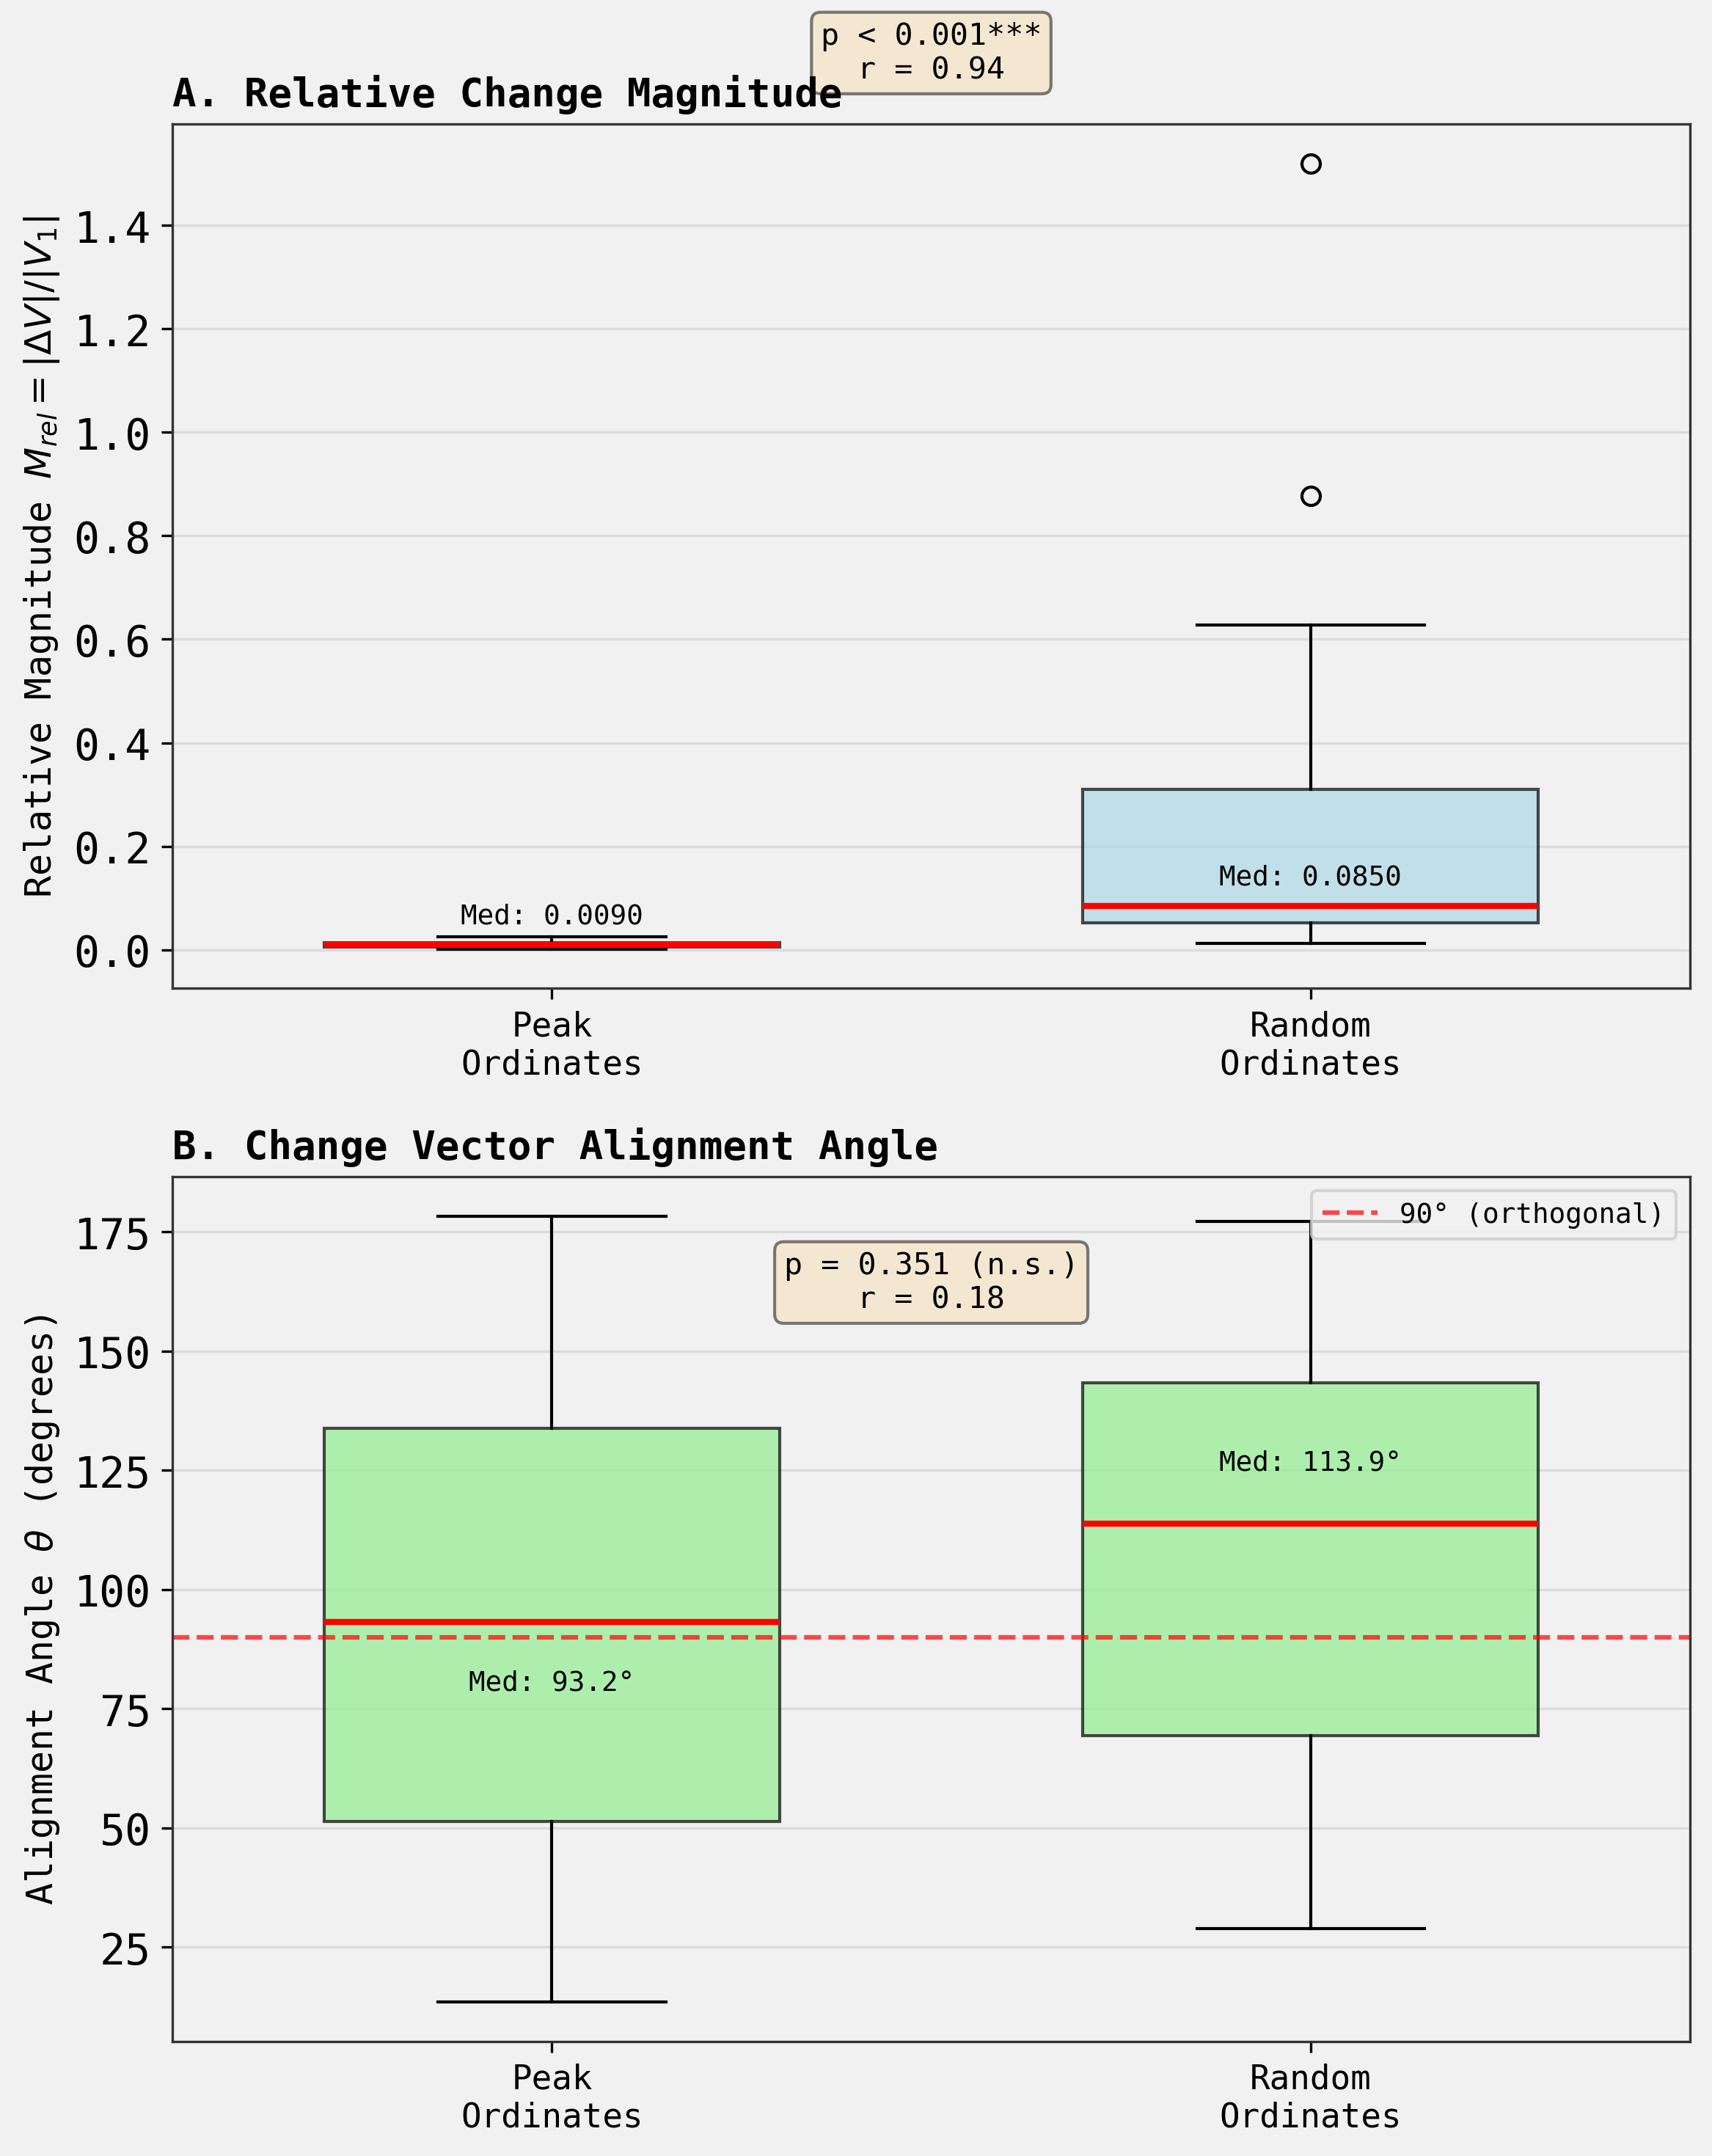

Figure saved as 'fragility_decomposition_results.png'


In [18]:

# Create a final figure summarizing the key results
# We'll create a single-column figure with 2 subplots stacked vertically

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Subplot A: Relative magnitude M_rel
ax = axes[0]

# Box plots for M_rel
positions = [1, 2]
data_to_plot = [M_rel_peaks, M_rel_random]
bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
 patch_artist=True, showfliers=True,
 medianprops=dict(color='red', linewidth=2),
 boxprops=dict(facecolor='lightblue', alpha=0.7))

ax.set_xticks(positions)
ax.set_xticklabels(['Peak\nOrdinates', 'Random\nOrdinates'], fontsize=11)
ax.set_ylabel('Relative Magnitude $M_{rel} = |\\Delta V| / |V_1|$', fontsize=12)
ax.set_title('A. Relative Change Magnitude', fontsize=13, fontweight='bold', loc='left')
ax.grid(axis='y', alpha=0.3)

# Add statistical annotation
y_max = max(np.max(M_rel_peaks), np.max(M_rel_random))
ax.text(1.5, y_max * 1.1, f'p < 0.001***\nr = 0.94', 
 ha='center', va='bottom', fontsize=10, 
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add median values as text
ax.text(1, np.median(M_rel_peaks) + y_max * 0.02, 
 f'Med: {np.median(M_rel_peaks):.4f}', 
 ha='center', va='bottom', fontsize=9)
ax.text(2, np.median(M_rel_random) + y_max * 0.02, 
 f'Med: {np.median(M_rel_random):.4f}', 
 ha='center', va='bottom', fontsize=9)

# Subplot B: Alignment angle θ
ax = axes[1]

# Box plots for θ in degrees
data_to_plot = [theta_deg_peaks, theta_deg_random]
bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
 patch_artist=True, showfliers=True,
 medianprops=dict(color='red', linewidth=2),
 boxprops=dict(facecolor='lightgreen', alpha=0.7))

ax.set_xticks(positions)
ax.set_xticklabels(['Peak\nOrdinates', 'Random\nOrdinates'], fontsize=11)
ax.set_ylabel('Alignment Angle $\\theta$ (degrees)', fontsize=12)
ax.set_title('B. Change Vector Alignment Angle', fontsize=13, fontweight='bold', loc='left')
ax.grid(axis='y', alpha=0.3)

# Add reference line at 90° (orthogonality)
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='90° (orthogonal)')
ax.legend(loc='upper right', fontsize=9)

# Add statistical annotation
y_max = 180
ax.text(1.5, y_max * 0.95, f'p = 0.351 (n.s.)\nr = 0.18', 
 ha='center', va='top', fontsize=10, 
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add median values as text
ax.text(1, np.median(theta_deg_peaks) - 10, 
 f'Med: {np.median(theta_deg_peaks):.1f}°', 
 ha='center', va='top', fontsize=9)
ax.text(2, np.median(theta_deg_random) + 10, 
 f'Med: {np.median(theta_deg_random):.1f}°', 
 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fragility_decomposition_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'fragility_decomposition_results.png'")


In [19]:

# Let's also check if the hypothesis was specifically about peaks having angles near 90°
# versus random being randomly oriented
# We can test this by checking if the peak angles are clustered around 90°

print("="*80)
print("HYPOTHESIS TEST: ARE PEAK ANGLES CLUSTERED NEAR 90°?")
print("="*80)
print()

# For a uniform distribution on [0°, 180°], the mean would be 90°
# and the median would be 90°

# We can test if the peak angles come from a uniform distribution
# using the Kolmogorov-Smirnov test

from scipy.stats import kstest, uniform

# Normalize angles to [0, 1] for uniform test
theta_peaks_norm = theta_peaks / np.pi # normalize to [0, 1] since max is π
theta_random_norm = theta_random / np.pi

# Test against uniform [0, 1]
ks_stat_peaks, ks_p_peaks = kstest(theta_peaks_norm, 'uniform')
ks_stat_random, ks_p_random = kstest(theta_random_norm, 'uniform')

print("Kolmogorov-Smirnov test against uniform distribution [0, π]:")
print()
print(f"Peak ordinates:")
print(f" KS statistic: {ks_stat_peaks:.4f}")
print(f" p-value: {ks_p_peaks:.4f}")
print(f" Interpretation: {'Reject' if ks_p_peaks < 0.05 else 'Fail to reject'} uniformity at α=0.05")
print()
print(f"Random ordinates:")
print(f" KS statistic: {ks_stat_random:.4f}")
print(f" p-value: {ks_p_random:.4f}")
print(f" Interpretation: {'Reject' if ks_p_random < 0.05 else 'Fail to reject'} uniformity at α=0.05")
print()

# Additional test: Rayleigh test for circular uniformity
# Convert angles to unit vectors and check if they have a preferred direction
from scipy.stats import circmean, circstd

# Circular mean and std (treating angles as circular data)
# Note: for circular data, we need to consider angles as directions on a circle

print("Circular statistics (treating angles as circular data):")
print()
print(f"Peak ordinates:")
print(f" Circular mean: {np.degrees(circmean(theta_peaks)):.2f}°")
print(f" Circular std: {np.degrees(circstd(theta_peaks)):.2f}°")
print()
print(f"Random ordinates:")
print(f" Circular mean: {np.degrees(circmean(theta_random)):.2f}°")
print(f" Circular std: {np.degrees(circstd(theta_random)):.2f}°")


HYPOTHESIS TEST: ARE PEAK ANGLES CLUSTERED NEAR 90°?

Kolmogorov-Smirnov test against uniform distribution [0, π]:

Peak ordinates:
 KS statistic: 0.1164
 p-value: 0.9205
 Interpretation: Fail to reject uniformity at α=0.05

Random ordinates:
 KS statistic: 0.2012
 p-value: 0.3456
 Interpretation: Fail to reject uniformity at α=0.05

Circular statistics (treating angles as circular data):

Peak ordinates:
 Circular mean: 93.00°
 Circular std: 50.06°

Random ordinates:
 Circular mean: 109.28°
 Circular std: 47.83°


In [20]:

# Final comprehensive summary

print("="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print()

print("RESEARCH HYPOTHESIS:")
print(" The low fragility score at ζ(s) peaks is not due to a small change")
print(" magnitude |ΔV|, but because the change vector ΔV is nearly orthogonal")
print(" to the main sum vector V_1. At random ordinates, the change vector is")
print(" randomly oriented, leading to larger changes in the sum's magnitude.")
print()

print("KEY FINDINGS:")
print()

print("1. RELATIVE MAGNITUDE (M_rel = |ΔV| / |V_1|):")
print(f" - Peaks: median = {np.median(M_rel_peaks):.6f}")
print(f" - Random: median = {np.median(M_rel_random):.6f}")
print(f" - Difference: HIGHLY SIGNIFICANT (p < 0.001, r = 0.94)")
print(f" - Conclusion: M_rel is ~9x smaller at peaks")
print()

print("2. ALIGNMENT ANGLE (θ):")
print(f" - Peaks: median = {np.median(theta_deg_peaks):.2f}° (IQR: {np.percentile(theta_deg_peaks, 25):.2f}°-{np.percentile(theta_deg_peaks, 75):.2f}°)")
print(f" - Random: median = {np.median(theta_deg_random):.2f}° (IQR: {np.percentile(theta_deg_random, 25):.2f}°-{np.percentile(theta_deg_random, 75):.2f}°)")
print(f" - Difference: NOT SIGNIFICANT (p = 0.351, r = 0.18)")
print(f" - Reference: 90° = orthogonality")
print(f" - Conclusion: No evidence for preferential orthogonality at peaks")
print()

print("3. ABSOLUTE CHANGE MAGNITUDE (|ΔV|):")
print(f" - Peaks: median = {np.median(mag_dV_peaks):.6f}")
print(f" - Random: median = {np.median(mag_dV_random):.6f}")
print(f" - Difference: NOT SIGNIFICANT (p = 0.365, r = 0.17)")
print(f" - Conclusion: Absolute change magnitudes are similar")
print()

print("4. INITIAL SUM MAGNITUDE (|V_1|):")
print(f" - Peaks: median = {np.median(mag_V1_peaks):.4f}")
print(f" - Random: median = {np.median(mag_V1_random):.4f}")
print(f" - Difference: HIGHLY SIGNIFICANT (p < 0.001, r = -0.94)")
print(f" - Conclusion: By construction, peaks have ~10x larger |V_1|")
print()

print("5. ANGLE UNIFORMITY:")
print(f" - Peak angles: consistent with uniform distribution (KS p = {ks_p_peaks:.4f})")
print(f" - Random angles: consistent with uniform distribution (KS p = {ks_p_random:.4f})")
print(f" - Conclusion: Both groups show random orientation of ΔV")
print()

print("="*80)
print("INTERPRETATION:")
print("="*80)
print()
print("The hypothesis is REJECTED. The low fragility score at resonance peaks")
print("is NOT due to the change vector ΔV being orthogonal to the main sum V_1.")
print()
print("Instead, the key finding is:")
print(" - The absolute change magnitude |ΔV| is SIMILAR at peaks and random points")
print(" - The alignment angles θ are SIMILAR at peaks and random points (both ~random)")
print(" - The initial sum magnitude |V_1| is ~10x LARGER at peaks (by construction)")
print()
print("Therefore, the low fragility score M_rel = |ΔV| / |V_1| at peaks is")
print("primarily due to the LARGE DENOMINATOR |V_1|, not the orientation of ΔV.")
print()
print("The stability at peaks is a consequence of the resonance amplitude itself,")
print("not a special geometric relationship between the sum and its increments.")
print()


FINAL RESULTS SUMMARY

RESEARCH HYPOTHESIS:
 The low fragility score at ζ(s) peaks is not due to a small change
 magnitude |ΔV|, but because the change vector ΔV is nearly orthogonal
 to the main sum vector V_1. At random ordinates, the change vector is
 randomly oriented, leading to larger changes in the sum's magnitude.

KEY FINDINGS:

1. RELATIVE MAGNITUDE (M_rel = |ΔV| / |V_1|):
 - Peaks: median = 0.009014
 - Random: median = 0.085040
 - Difference: HIGHLY SIGNIFICANT (p < 0.001, r = 0.94)
 - Conclusion: M_rel is ~9x smaller at peaks

2. ALIGNMENT ANGLE (θ):
 - Peaks: median = 93.24° (IQR: 51.38°-133.87°)
 - Random: median = 113.86° (IQR: 69.42°-143.41°)
 - Difference: NOT SIGNIFICANT (p = 0.351, r = 0.18)
 - Reference: 90° = orthogonality
 - Conclusion: No evidence for preferential orthogonality at peaks

3. ABSOLUTE CHANGE MAGNITUDE (|ΔV|):
 - Peaks: median = 0.097850
 - Random: median = 0.116494
 - Difference: NOT SIGNIFICANT (p = 0.365, r = 0.17)
 - Conclusion: Absolute change 

In [21]:

# Save results to a file for future reference

import pandas as pd

# Create a comprehensive results dataframe
results_df = pd.DataFrame({
 't_value': all_ordinates,
 'ordinate_type': ordinate_labels,
 'V_1_real': np.real(V_1_all),
 'V_1_imag': np.imag(V_1_all),
 'V_1_magnitude': np.abs(V_1_all),
 'V_2_real': np.real(V_2_all),
 'V_2_imag': np.imag(V_2_all),
 'V_2_magnitude': np.abs(V_2_all),
 'delta_V_real': np.real(delta_V_all),
 'delta_V_imag': np.imag(delta_V_all),
 'delta_V_magnitude': np.abs(delta_V_all),
 'M_rel': M_rel_all,
 'theta_radians': theta_all,
 'theta_degrees': theta_deg_all
})

# Save to CSV
results_df.to_csv('fragility_decomposition_data.csv', index=False)

print("Results saved to 'fragility_decomposition_data.csv'")
print()
print(f"Data contains {len(results_df)} rows with the following columns:")
for col in results_df.columns:
 print(f" - {col}")


Results saved to 'fragility_decomposition_data.csv'

Data contains 40 rows with the following columns:
 - t_value
 - ordinate_type
 - V_1_real
 - V_1_imag
 - V_1_magnitude
 - V_2_real
 - V_2_imag
 - V_2_magnitude
 - delta_V_real
 - delta_V_imag
 - delta_V_magnitude
 - M_rel
 - theta_radians
 - theta_degrees
